<div style="background:linear-gradient(135deg,#083344 0%,#0e7490 55%,#06b6d4 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a5f3fc;font-weight:700;text-transform:uppercase">Chapter 87 · Case Study · Inference</div>
  <div style="font-size:33px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: A Customer Satisfaction Survey 📝</div>
  <div style="font-size:15px;color:#ecfeff;max-width:760px;line-height:1.6">Survey data is gloriously mixed: a yes/no recommend, categorical plans, and an ordinal 1-5 rating. We put a margin of error on the headline rate, test whether recommending depends on plan with chi-square, and compare satisfaction across segments with a rank-based test.</div>
  <div style="margin-top:16px;font-size:13px;color:#a5f3fc">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
CY="#0891b2"; DEEP="#0e7490"; LIGHT="#67e8f9"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(87)

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 1 · THE QUESTION & THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What do the survey numbers really say?</div>
<div style="color:#4a5578;margin-top:6px">A customer survey recorded a 1-5 satisfaction rating, whether each respondent would recommend (the top-2-box metric), their plan, and their segment. Three questions: what share would recommend (with a margin of error)? is recommending linked to plan? do new and existing customers differ in satisfaction?</div>
</div>

In [2]:
try:    d = pd.read_excel("../../data/ch87_satisfaction_survey.xlsx", sheet_name="Responses")
except FileNotFoundError: d = pd.read_excel(BASE+"ch87_satisfaction_survey.xlsx", sheet_name="Responses")
print("loaded:", d.shape)
print("would-recommend rate:", f"{d.would_recommend.mean():.1%}")
print(pd.crosstab(d.plan, d.would_recommend, normalize="index").round(3))

loaded: (720, 7)
would-recommend rate: 64.3%
would_recommend      0      1
plan                         
Basic            0.404  0.596
Enterprise       0.212  0.788
Pro              0.355  0.645


Survey data mixes a yes/no (recommend), two categoricals (plan, segment), and an ordinal rating (1-5). Each question type needs its own tool, and the survey is a sample, so every headline number needs a margin of error, not a false air of precision.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 · THREE QUESTIONS, THREE TESTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A proportion, an association, and an ordinal comparison</div>
<div style="color:#4a5578;margin-top:6px">Q1 a single RATE -> one-proportion estimate with a margin of error. Q2 two CATEGORICAL variables (plan x recommend) -> chi-square test of independence. Q3 an ORDINAL rating (1-5) across two groups -> Mann-Whitney U (ranks, not means, because 1-5 is ordinal).</div>
</div>

In [3]:
print("Q1 share who would recommend    -> proportion + 95% margin of error")
print("Q2 plan vs would_recommend         -> CHI-SQUARE test of independence")
print("   H0: recommending is independent of plan     H1: they are associated")
print("Q3 satisfaction (1-5): new vs existing -> MANN-WHITNEY U (ordinal)")
print("   H0: same distribution            H1: the groups differ")

Q1 share who would recommend    -> proportion + 95% margin of error
Q2 plan vs would_recommend         -> CHI-SQUARE test of independence
   H0: recommending is independent of plan     H1: they are associated
Q3 satisfaction (1-5): new vs existing -> MANN-WHITNEY U (ordinal)
   H0: same distribution            H1: the groups differ


A 1-5 rating is <em>ordinal</em>, the gap from 1 to 2 is not guaranteed equal to 4 to 5, so we compare ranks with Mann-Whitney rather than means with a t-test. And a chi-square needs expected counts of at least ~5 per cell, which we will check.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 3 · RUN THE ANALYSIS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Margin of error, chi-square, and the rank test</div>
<div style="color:#4a5578;margin-top:6px">We report the recommend rate with its margin of error, test plan-vs-recommend with chi-square (plus Cramer's V for strength), and compare satisfaction across segments with Mann-Whitney.</div>
</div>

In [4]:
rec=d.would_recommend; n=len(rec); phat=rec.mean(); moe=1.96*np.sqrt(phat*(1-phat)/n)
print(f"Q1 recommend = {phat:.1%}  +/- {moe*100:.1f} pts  (95%); true rate likely in [{(phat-moe)*100:.1f}%, {(phat+moe)*100:.1f}%]")
ct=pd.crosstab(d.plan, d.would_recommend)
chi2,p,dof,expected=stats.chi2_contingency(ct)
V=np.sqrt(chi2/(n*(min(ct.shape)-1)))
print(f"Q2 plan x recommend: chi2={chi2:.2f}, dof={dof}, p={p:.4f}, Cramer V={V:.3f}, min expected={expected.min():.1f}")
print("   -> reject H0: recommending depends on plan" if p<0.05 else "   -> independent")

Q1 recommend = 64.3%  +/- 3.5 pts  (95%); true rate likely in [60.8%, 67.8%]
Q2 plan x recommend: chi2=13.74, dof=2, p=0.0010, Cramer V=0.138, min expected=40.3
   -> reject H0: recommending depends on plan


Q3 satisfaction: new mean=3.58 (median 4) vs existing mean=3.99 (median 4)
   Mann-Whitney U=49469, p=2.47e-08  -> groups differ


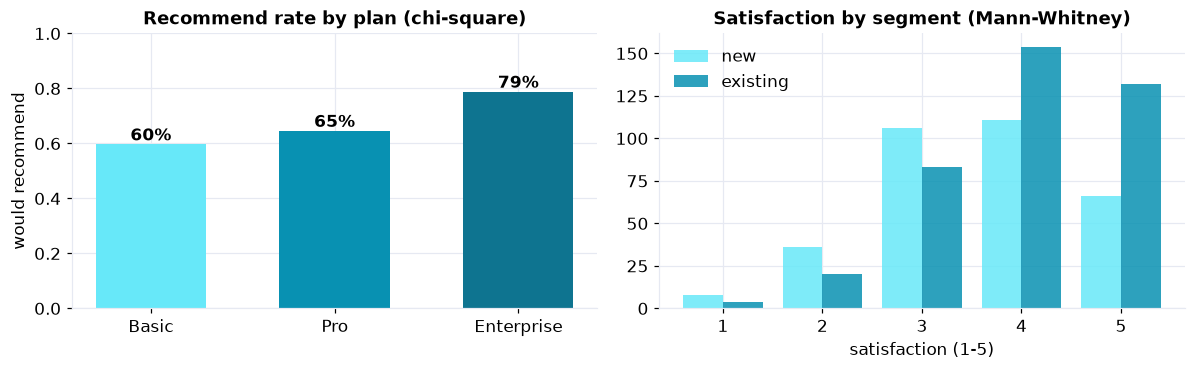

In [5]:
new=d[d.segment=="new"].satisfaction_1_5; ex=d[d.segment=="existing"].satisfaction_1_5
u,pu=stats.mannwhitneyu(new, ex, alternative="two-sided")
print(f"Q3 satisfaction: new mean={new.mean():.2f} (median {new.median():.0f}) vs existing mean={ex.mean():.2f} (median {ex.median():.0f})")
print(f"   Mann-Whitney U={u:.0f}, p={pu:.2e}  -> {'groups differ' if pu<0.05 else 'no difference'}")
fig,ax=plt.subplots(1,2,figsize=(11,3.5))
rates=d.groupby("plan").would_recommend.mean().reindex(["Basic","Pro","Enterprise"])
ax[0].bar(rates.index,rates.values,color=[LIGHT,CY,DEEP],width=0.6)
for i,v in enumerate(rates.values): ax[0].text(i,v+0.015,f"{v:.0%}",ha="center",fontweight="bold")
ax[0].set_ylim(0,1); ax[0].set_ylabel("would recommend"); ax[0].set_title("Recommend rate by plan (chi-square)")
bins=np.arange(0.5,6.5,1)
ax[1].hist([new,ex],bins=bins,label=["new","existing"],color=[LIGHT,CY],alpha=0.85)
ax[1].set_xticks([1,2,3,4,5]); ax[1].set_xlabel("satisfaction (1-5)"); ax[1].set_title("Satisfaction by segment (Mann-Whitney)"); ax[1].legend()
plt.tight_layout(); plt.show()

The recommend rate is <strong>64% &#177; 3.5 points</strong>, so the true rate is very likely between about 61% and 68%, never report 64% as if it were exact. Recommending clearly depends on plan (chi-square p &#8776; 0.001), though Cramer&#39;s V &#8776; 0.14 says the link is <em>modest</em>: higher-tier plans recommend more, but plan is not destiny. And existing customers rate satisfaction higher than new ones (Mann-Whitney p &#8776; 10&#8315;&#8312;) even though both medians are 4, the rank test detects the shift in the whole distribution that a glance at the medians would miss.

<div style="background:#ffffff;border:1px solid #cffafe;border-left:5px solid #0e7490;border-radius:12px;padding:18px 22px;font-family:Inter,sans-serif">
<div style="font-size:12px;font-weight:800;color:#0e7490;letter-spacing:1px">📋 STATISTICIAN’S REPORT</div>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin:4px 0 8px">Read-out: a solid score, with a clear lever and a caveat</div>
<div style="color:#3f4a63;line-height:1.75"><strong>What we found.</strong> About <strong>64%</strong> of customers would recommend us, with a margin of error of <strong>&#177;3.5 points</strong> (so realistically 61-68%). Willingness to recommend <strong>rises with plan tier</strong> (the association is statistically clear, p &#8776; 0.001), and <strong>existing customers are more satisfied than new ones</strong> (a real difference, p &#8776; 0.0000001). <br><br><strong>What it means.</strong> The headline 64% is healthy but should always be quoted as a range, not a point. The plan link is real but <em>modest</em> (it explains only a small slice of who recommends), so 'upsell to Pro' is a lever, not a cure. The new-vs-existing gap points to an onboarding or early-experience opportunity: newer customers are measurably less satisfied. <br><br><strong>What to do.</strong> Track the recommend rate with its margin of error over time (don&#39;t over-react to a 1-2 point wobble), and run a focused review of the new-customer onboarding experience. <br><br><strong>Caveats.</strong> Surveys suffer non-response and self-selection, the people who answer may not represent everyone, so treat these as directional. And because satisfaction is a 1-5 ordinal scale, we compared ranks, not averages, on purpose.</div>
</div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>